In [1]:
using CairoMakie
CairoMakie.activate!()
Makie.inline!(true)

true

In [2]:
g(x) = abs(x) > 1 ? 0 : 1 - abs(x)

g (generic function with 1 method)

In [3]:
xs = range(-5, 5, length=500)
time = Observable(0.0)
gfun = @lift g.(xs .- $time);

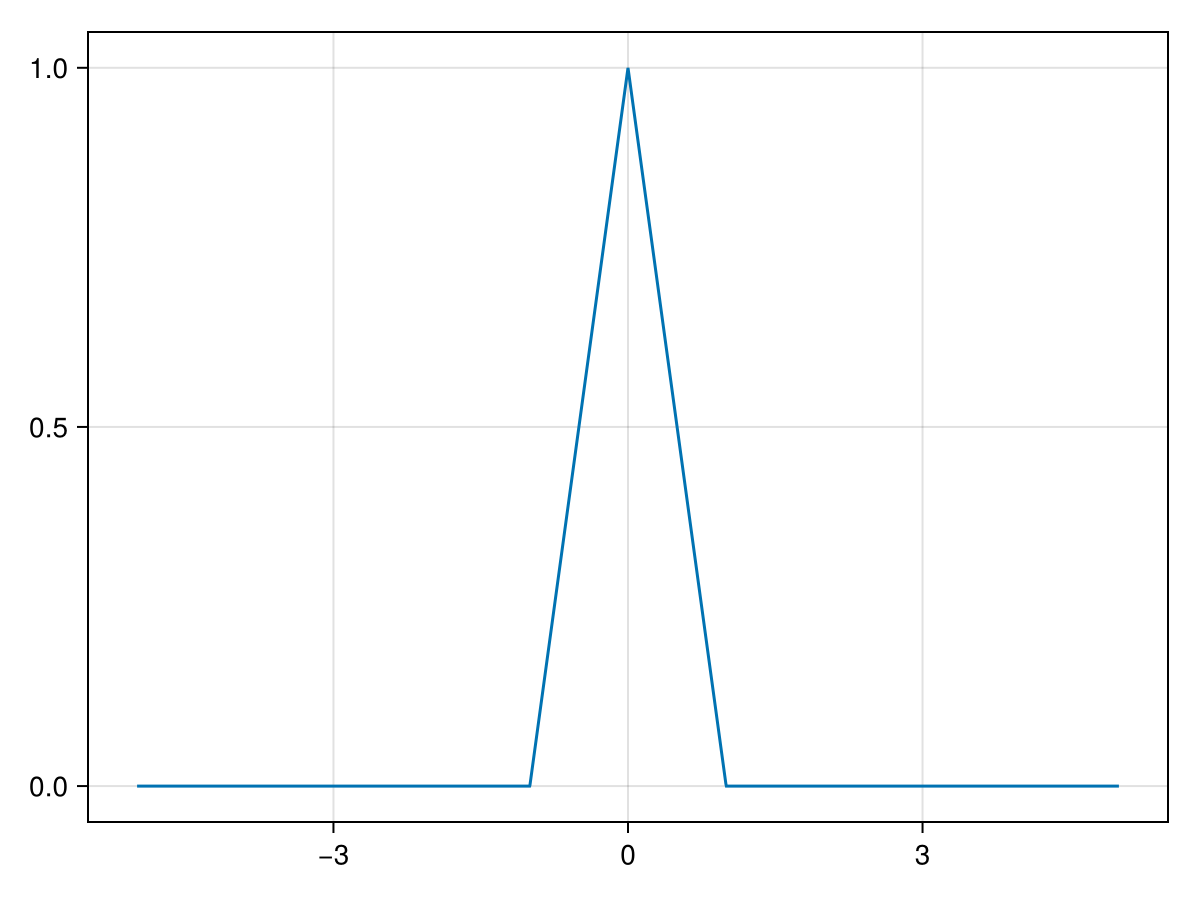

In [4]:
fig = lines(-5..5, g)

In [5]:
save("../../assets/plots/animations/triangle.png", fig)

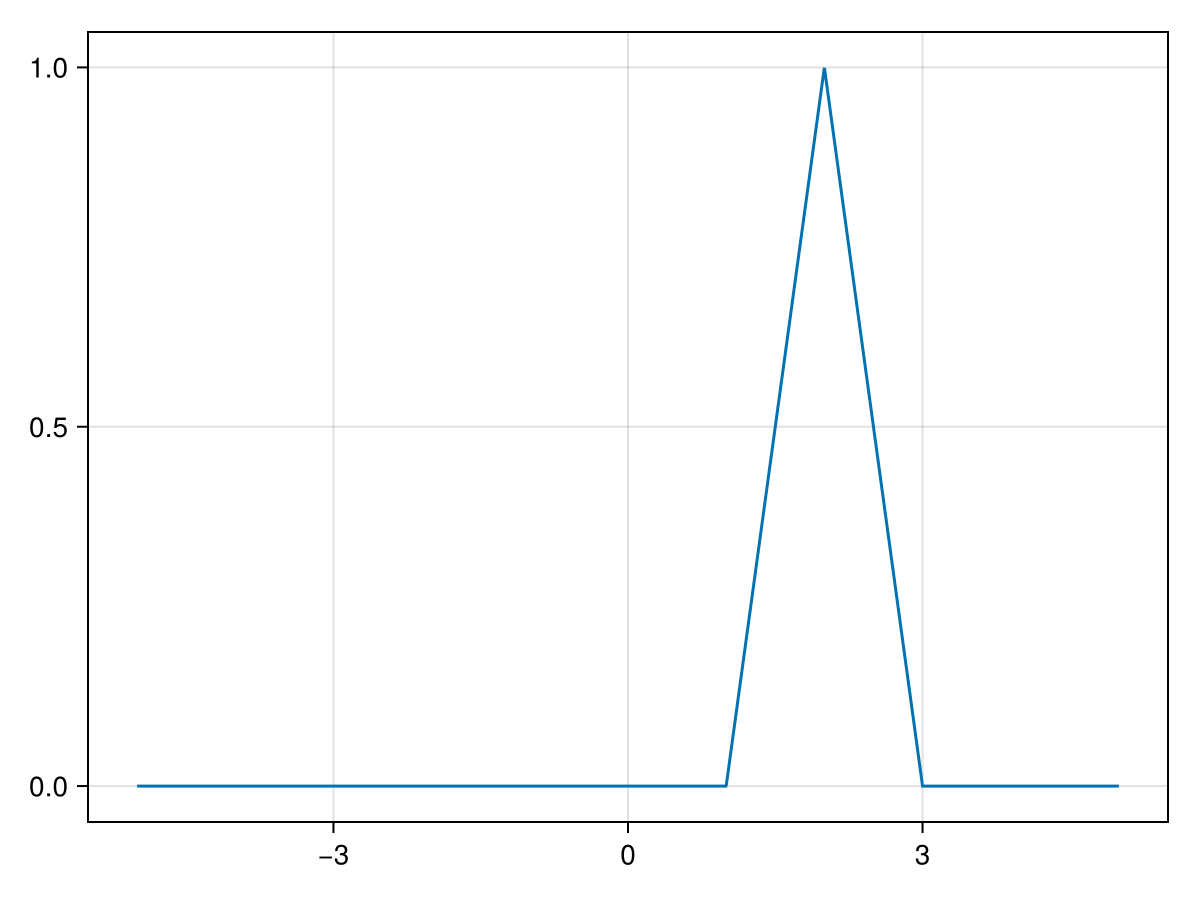

In [6]:
fig = lines(-5..5, x->g(x-2))

In [7]:
save("../../assets/plots/animations/triangle2.png", fig)

In [8]:
xs = range(-5, 5, length=500)
time = Observable(0.0)
gfun = @lift g.(xs .- $time);

fig = Figure()
ax = Axis(fig[1, 1],
  limits=(-5, 5, -0.1, 1),
  title=@lift("t = $(round($time, digits = 1))")
)
lines!(ax, xs, gfun)
timestamps = range(0, 5, step=1 / 30)
record(fig, "../../assets/plots/animations/triangle.mp4", timestamps; framerate=30) do t
  time[] = t
end

"../../assets/plots/animations/triangle.mp4"

## Observables

In [10]:
x = Observable(0)

Observable(0)


In [11]:
typeof(x)

Observable{Int64}

In [12]:
x

Observable(0)


In [13]:
x[] = 5

5

In [14]:
x

Observable(5)


In [15]:
trigger1 = on(x) do x
  println("New value of x is $x")
end

ObserverFunction defined at /Users/pstaab/code/sci-comp-book/julia-output/plots/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:2 operating on Observable(5)

In [16]:
x[] = 4

New value of x is 4


4

In [17]:
x[] = 8

New value of x is 8


8

In [18]:
for i=1:5
  x[] = i
end

New value of x is 1
New value of x is 2
New value of x is 3
New value of x is 4
New value of x is 5


In [19]:
trigger2 = on(x) do x
  println("Another trigger.  x: $x")
end

ObserverFunction defined at /Users/pstaab/code/sci-comp-book/julia-output/plots/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X25sZmlsZQ==.jl:2 operating on Observable(5)

In [20]:
x[] = 6

New value of x is 6
Another trigger.  x: 6


6

In [21]:
off(trigger2)

true

In [22]:
2*x

MethodError: MethodError: no method matching *(::Int64, ::Observable{Int64})
The function `*` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  *(::Any, ::Any, !Matched::Any, !Matched::Any...)
   @ Base operators.jl:650
  *(!Matched::ChainRulesCore.NotImplemented, ::Any)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/IZ7FD/src/tangent_arithmetic.jl:37
  *(!Matched::ChainRulesCore.NoTangent, ::Any)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/IZ7FD/src/tangent_arithmetic.jl:64
  ...


In [23]:
2*x[]

12

In [24]:
to_value(x)

6

In [25]:
to_value(3)

3

In [26]:
to_value("Hello world")

"Hello world"

In [27]:
y = lift(x -> x^2, x)

Observable(36)


In [28]:
x[] = 7

New value of x is 7


7

In [29]:
y

Observable(49)


### @lift macro

In [30]:
a = Observable(1.0)
b = Observable(6.0)
c = Observable(10.0)
mean(a,b,c) = (a+b+c)/3
m = lift(mean,a,b,c)

Observable(5.666666666666667)


In [31]:
m = @lift(($a + $b + $c) / 3)

Observable(5.666666666666667)


## More animations

In [40]:
grid = range(-pi, pi, length=100)
xs = [x for x in grid, y in grid]
ys = [y for x in grid, y in grid]
time = Observable(0.0)
zs = @lift sin.(xs.^2 .+ ys.^2 .- $time )

fig = Figure()
ax = Axis3(fig[1, 1],
  limits=(-pi, pi, -pi, pi, -1, 1),
  title=@lift("t = $(round($time, digits = 1))")
)
surface!(ax, xs, ys, zs)
timestamps = range(0, 10, step=1 / 10)
record(fig, "../../assets/plots/animations/sine-wave.mp4", timestamps; framerate=30) do t
  time[] = t
end

"../../assets/plots/animations/sine-wave.mp4"